In [3]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

'sudo'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'sudo'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

In [5]:
# 데이터 생성
np.random.seed(2025)
satisfaction = np.random.normal(7.5, 1.5, 1000)
satisfaction = np.clip(satisfaction, 1, 10)
df1 = pd.DataFrame({'score': satisfaction})

문제 1. 기초통계량 계산

- 평균, 중앙값, 최빈값, 표준편차를 계산해 봅시다.
- 히스토그램을 그리고 평균과 중앙값 선으로 표시해 봅시다.
- 데이터의 분포 형태를 해석한 후, 마케팅 전략 수립에 어떻게 활용할 수 있을지 생각해 봅시다.

=== 고객 만족도 기술통계 ===
평균(Mean)     : 7.43
중앙값(Median) : 7.42
최빈값(Mode)   : 10.00
표준편차(Std)  : 1.39
왜도(Skewness) : -0.165


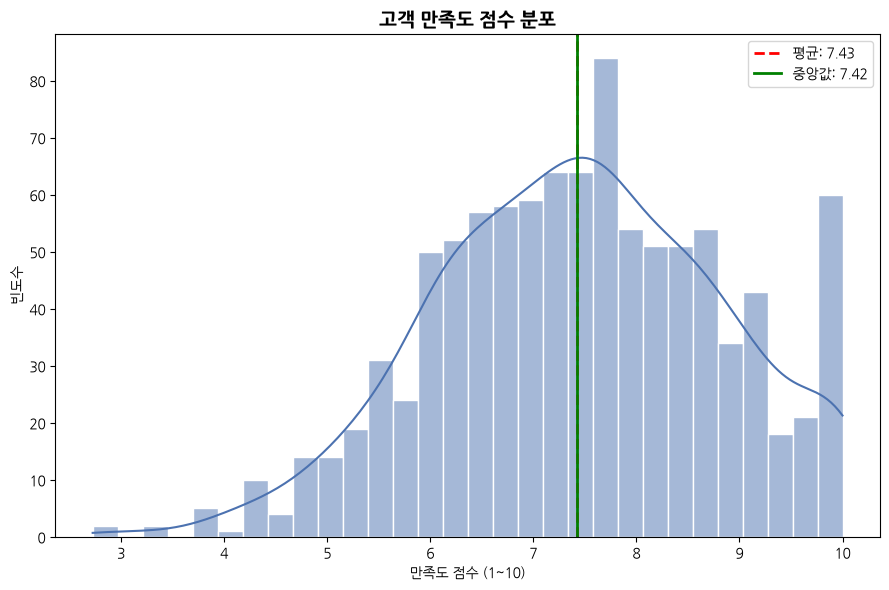

In [6]:

# 1-1. 기술통계량 계산
from scipy import stats


mean_val = df1['score'].mean()
median_val = df1['score'].median()
mode_val = df1['score'].round(1).mode()[0]  # 연속형이라 소수1자리로 반올림 후 최빈값
std_val = df1['score'].std()
 
print("=== 고객 만족도 기술통계 ===")
print(f"평균(Mean)     : {mean_val:.2f}")
print(f"중앙값(Median) : {median_val:.2f}")
print(f"최빈값(Mode)   : {mode_val:.2f}")
print(f"표준편차(Std)  : {std_val:.2f}")
print(f"왜도(Skewness) : {stats.skew(df1['score']):.3f}")
 
# 1-2. 히스토그램 + 평균/중앙값 선
plt.figure(figsize=(9, 6))
sns.histplot(df1['score'], bins=30, kde=True, color='#4C72B0', edgecolor='white')
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'평균: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'중앙값: {median_val:.2f}')
plt.title('고객 만족도 점수 분포', fontsize=14, fontweight='bold')
plt.xlabel('만족도 점수 (1~10)')
plt.ylabel('빈도수')
plt.legend()
plt.tight_layout()
plt.savefig('satisfaction_histogram.png', dpi=150)
plt.show()

고객 대다수가 "불만은 아니지만 열광적이지도 않은" 중간~상위 구간(6~9점)에 몰려 있다는 것은, 이들이 이탈 위험은 낮지만 자발적 추천(구전)으로 이어지기는 어려운 수동적 고객층임을 의미한다. 해당 고객층을 대상으로 하는 만족도 향상 프로모션을 기획하는 것이 가장 효과적일 것으로 기대된다.

문제 2. 평균 vs 중앙값 비교

- 각 지역의 평균 연봉과 중앙값을 구해 봅시다.
- 지역별 박스플롯(Boxplot)을 그려서 분포의 차이를 시각적으로 확인해 봅시다.

=== 지역별 연봉 통계 (단위: 만원) ===
           평균    중앙값   표준편차
region                     
A       292.5  294.3   46.5
B       347.6  287.3  290.4


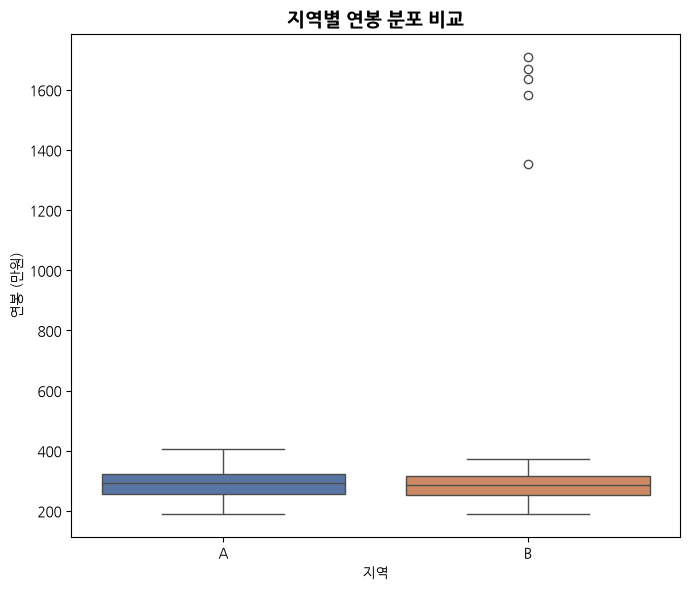

In [7]:

# 데이터 생성
np.random.seed(2025)

# A 지역: 평균 300, 표준편차 50
region_a = np.random.normal(300, 50, 100)

# B 지역: 일반 소득자 + 극단적인 고소득자 포함
region_b = np.concatenate([
    np.random.normal(280, 40, 95),    # 일반 소득자 95명
    np.random.normal(1500, 200, 5)    # 고소득자 5명
])

df2 = pd.DataFrame({
    'region': ['A'] * 100 + ['B'] * 100,
    'salary': np.concatenate([region_a, region_b])
})

# 2-1. 지역별 평균/중앙값 계산
summary = df2.groupby('region')['salary'].agg(
    평균='mean', 중앙값='median', 표준편차='std'
).round(1)
 
print("=== 지역별 연봉 통계 (단위: 만원) ===")
print(summary)
 
# 2. 지역별 박스플롯
plt.figure(figsize=(7, 6))
sns.boxplot(data=df2, x='region', y='salary', hue='region',
            palette={'A': '#4C72B0', 'B': '#DD8452'}, legend=False)
plt.title('지역별 연봉 분포 비교', fontsize=14, fontweight='bold')
plt.xlabel('지역')
plt.ylabel('연봉 (만원)')
plt.tight_layout()
plt.savefig('salary_boxplot_by_region.png', dpi=150)
plt.show()

문제 3. 이상값과 분산 비교

- 각 반의 평균, 표준편차, 최소/최대값을 계산해 봅시다.
- 박스플롯을 사용하여 두 반의 분포 차이를 시각적으로 비교해 봅시다.
- 이상값이 통계 지표에 어떤 영향을 주는지 생각해 봅시다.

=== 반별 점수 기술통계 ===
          평균   표준편차    최소값     최대값
class                             
1반     75.72   7.06  60.69   92.18
2반     73.73  22.34   0.00  130.00


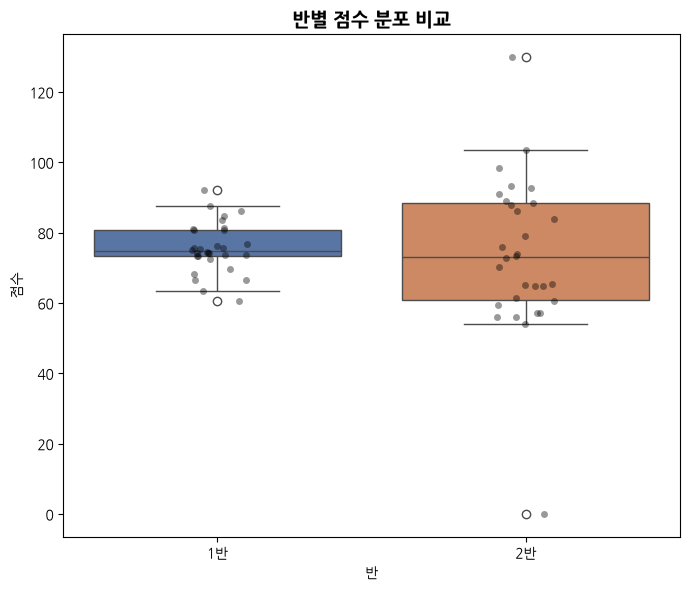

In [8]:
# 데이터 생성
np.random.seed(2025)  # 재현 가능성을 위해 시드 고정

# 1반: 평균 75, 표준편차 8
class1 = np.random.normal(75, 8, 30)

# 2반: 일반 학생 + 이상값(0점, 130점)
class2 = np.concatenate([
    np.random.normal(75, 15, 28),  # 일반 학생
    [0, 130]                       # 극단적인 이상값
])

df3 = pd.DataFrame({
    'class': ['1반'] * 30 + ['2반'] * 30,
    'score': np.concatenate([class1, class2])
})

# 3-1. 반별 기술통계량 계산
stats_by_class = df3.groupby('class')['score'].agg(
    평균='mean', 표준편차='std', 최소값='min', 최대값='max'
)
print("=== 반별 점수 기술통계 ===")
print(stats_by_class.round(2))

# 3-2. 박스플롯으로 분포 비교
plt.figure(figsize=(7, 6))
sns.boxplot(data=df3, x='class', y='score', hue='class', palette=['#4C72B0', '#DD8452'], legend=False)
sns.stripplot(data=df3, x='class', y='score', color='black', alpha=0.4, jitter=True)
plt.title('반별 점수 분포 비교', fontsize=14, fontweight='bold')
plt.xlabel('반')
plt.ylabel('점수')
plt.tight_layout()
plt.savefig('class_boxplot.png', dpi=150)
plt.show()

# 3-3. 이상값이 통계 지표에 미치는 영향 확인

**해석**

- 1반은 평균 75.72점, 표준편차 7.06점으로 안정적인 분포
- 2반은 평균 73.73점, 표준편차 22.34점으로, 이상값(0점, 130점)을 제외하면 평균 74.35점, 표준편차 14.47점
- 즉 극단적인 이상값 2개가 평균에는 큰 영향을 주지 않지만(0.6점 차이), 표준편차는 큰 차이(14.47 → 22.34).
- 평균과 표준편차는 이상값에 민감한 지표이므로, 이상값이 의심되는 데이터에서는 중앙값(median)이나 사분위범위(IQR) 같은 이상값에 덜 민감한 지표를 함께 확인하는 것이 타당.
- 박스플롯에서도 2반의 박스는 좁게 유지되지만, 0점과 130점이 수염(whisker) 바깥의 점으로 표시되어 이상값의 존재를 시각적으로 바로 확인 가능.


문제 4. IQR 이상값 제거

- 2반의 점수 데이터를 대상으로 IQR 기준을 사용해 이상값을 판별하고 제거해 봅시다.
- 이상값 제거 전과 제거 후의 평균을 각각 계산해 봅시다.
- 이상값 제거가 평균에 어떤 영향을 주는지 설명해 봅시다.
- 필요하다면 중앙값과도 비교해 봅시다.

In [9]:
# 1. 2반 점수 데이터 추출
class2_score = df3[df3['class'] == '2반']['score']

# 2. IQR 기준으로 이상값 판별
Q1 = class2_score.quantile(0.25)
Q3 = class2_score.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = class2_score[(class2_score < lower_bound) | (class2_score > upper_bound)]
class2_removed = class2_score[(class2_score >= lower_bound) & (class2_score <= upper_bound)]

print("=== IQR 이상값 판별 ===")
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"정상 범위: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"이상값: {outliers.tolist()}")

# 3. 이상값 제거 전/후 평균 비교
mean_before = class2_score.mean()
mean_after = class2_removed.mean()
median_before = class2_score.median()
median_after = class2_removed.median()

print("\n=== 이상값 제거 전/후 비교 ===")
print(f"평균 - 제거 전: {mean_before:.2f}, 제거 후: {mean_after:.2f} (차이: {mean_before - mean_after:.2f})")
print(f"중앙값 - 제거 전: {median_before:.2f}, 제거 후: {median_after:.2f} (차이: {median_before - median_after:.2f})")


=== IQR 이상값 판별 ===
Q1: 60.75, Q3: 88.37, IQR: 27.61
정상 범위: [19.33, 129.79]
이상값: [0.0, 130.0]

=== 이상값 제거 전/후 비교 ===
평균 - 제거 전: 73.73, 제거 후: 74.35 (차이: -0.62)
중앙값 - 제거 전: 73.00, 제거 후: 73.00 (차이: 0.00)


- 평균: 제거 전 73.73점 → 제거 후 74.35점 (0.62점 차이). 이상값(0점, 130점)이 서로 반대 방향으로 어느 정도 상쇄되고, 전체 표본(30개) 대비 개수가 적어 평균에 미치는 영향은 크지 않는다. 
- 중앙값: 제거 전후 모두 73.00점으로 전혀 변하지 않습니다. 중앙값은 값의 크기 자체가 아니라 순위(가운데 위치)만 보기 때문에, 극단값이 있어도 그 순위가 맨 끝에 위치하는 한 중앙값에는 영향을 주지 않는다.
- 결론: 평균은 이상값에 민감하고, 중앙값은 이상값에 강건(robust)합니다. 그래서 이상값이 의심되는 데이터를 요약할 때는 평균만 보지 말고 중앙값을 함께 확인하는 것이 안전하다.

문제 5. 변수 유형 분류

- 아래 데이터에서 변수의 유형(연속형, 범주형, 이산형 등)을 구분해 봅시다.
- 변수의 의미를 고려하여 어떤 분석 방식이 적절한지도 함께 생각해 봅시다.

In [10]:
# 데이터 생성
np.random.seed(2025)
df5 = pd.DataFrame({
    'age': np.random.randint(18, 65, 200),
    'coffee_type': np.random.choice(['아메리카노', '라떼', '카페모카'], 200),
    'size': np.random.choice(['Small', 'Medium', 'Large'], 200),
    'price': np.random.normal(4500, 500, 200),
    'satisfaction': np.random.randint(1, 6, 200)
})

# 5-1. 변수 유형 정리
var_types = pd.DataFrame({
    '변수명': ['age', 'coffee_type', 'size', 'price', 'satisfaction'],
    '의미': ['고객 나이', '커피 종류', '음료 사이즈', '가격', '만족도(1~5점)'],
    '유형': ['연속형(비율척도)', '범주형(명목척도)', '범주형(순서척도)', '연속형(비율척도)', '이산형(순서척도)'],
    '적절한 분석': [
        '평균/표준편차, 히스토그램, 상관·회귀분석',
        '빈도표, 최빈값, 막대그래프, 카이제곱 검정',
        '빈도표(순서 유지), 순위 기반 검정(Kruskal-Wallis)',
        '평균/표준편차, 히스토그램·박스플롯, t검정·ANOVA, 회귀분석',
        '최빈값·중앙값, 막대그래프, 스피어만 상관, 순서형 회귀'
    ]
})

print(df5.dtypes)
print()
print(var_types.to_string(index=False))

age               int32
coffee_type         str
size                str
price           float64
satisfaction      int32
dtype: object

         변수명        의미        유형                               적절한 분석
         age     고객 나이 연속형(비율척도)              평균/표준편차, 히스토그램, 상관·회귀분석
 coffee_type     커피 종류 범주형(명목척도)             빈도표, 최빈값, 막대그래프, 카이제곱 검정
        size    음료 사이즈 범주형(순서척도) 빈도표(순서 유지), 순위 기반 검정(Kruskal-Wallis)
       price        가격 연속형(비율척도) 평균/표준편차, 히스토그램·박스플롯, t검정·ANOVA, 회귀분석
satisfaction 만족도(1~5점) 이산형(순서척도)      최빈값·중앙값, 막대그래프, 스피어만 상관, 순서형 회귀
